# key Results

In [ ]:
# We create four plots that tell the complete story:
#  when bots strike, what their signature looks like, which videos are connected in networks,
#  and how the enforcement queue is distributed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
video_features = pd.read_csv("data/processed/engineered_video_features_final.csv")

In [5]:
# Recalculate suspicious_hours if not in memory
if 'suspicious_hours' not in globals():
    peak_counts = video_features['peak_hour'].value_counts()
    mean_peaks = peak_counts.mean()
    std_peaks = peak_counts.std()
    suspicious_hours = peak_counts[peak_counts > mean_peaks + 1.5 * std_peaks].index.tolist()
    print(f"Recalculated suspicious_hours: {sorted(suspicious_hours)}")

Recalculated suspicious_hours: [12]


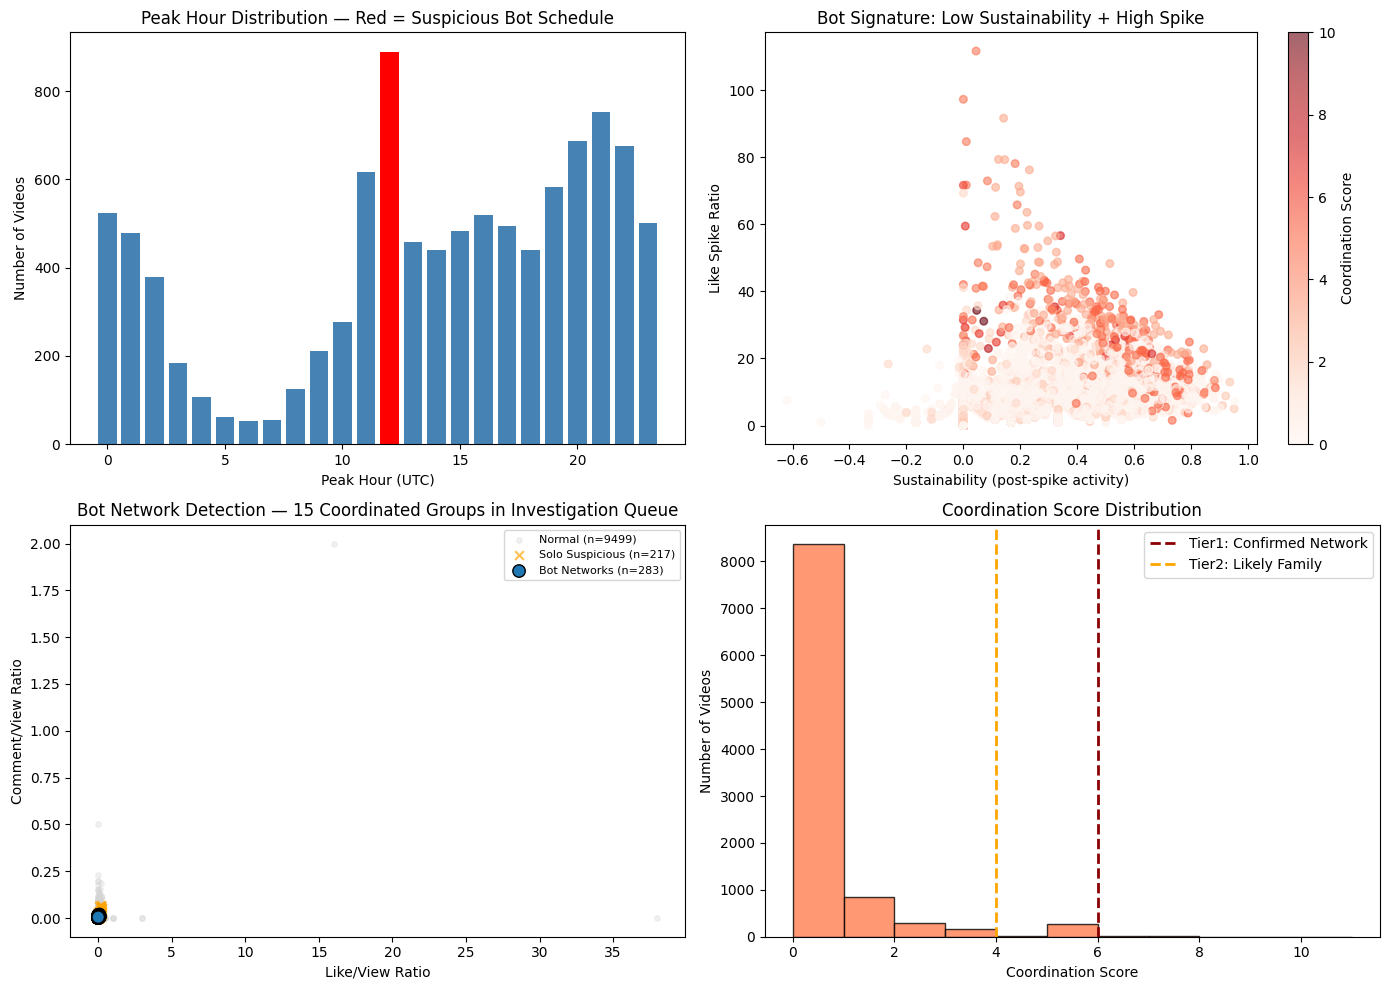

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PLOT 1: Peak Hour Distribution ---
ax1 = axes[0, 0]
hour_counts = video_features['peak_hour'].value_counts().sort_index()
colors = ['red' if h in suspicious_hours else 'steelblue' for h in hour_counts.index]
ax1.bar(hour_counts.index, hour_counts.values, color=colors)
ax1.set_xlabel('Peak Hour (UTC)')
ax1.set_ylabel('Number of Videos')
ax1.set_title('Peak Hour Distribution — Red = Suspicious Bot Schedule')

# --- PLOT 2: Sustainability vs Like Spike Ratio ---
ax2 = axes[0, 1]
scatter = ax2.scatter(
    video_features['sustainability'], 
    video_features['like_spike_ratio'],
    c=video_features['coordination_score'],
    cmap='Reds', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=ax2, label='Coordination Score')
ax2.set_xlabel('Sustainability (post-spike activity)')
ax2.set_ylabel('Like Spike Ratio')
ax2.set_title('Bot Signature: Low Sustainability + High Spike')

# --- PLOT 3: Bot Networks (only suspicious + clustered) ---
ax3 = axes[1, 0]

# Plot all normal videos as light gray
normal = video_features[~video_features['is_suspicious_v2']]
ax3.scatter(normal['like_view_ratio'], normal['comment_view_ratio'], 
            c='lightgray', alpha=0.3, s=15, label=f'Normal (n={len(normal)})')

# Plot suspicious videos NOT in networks as orange
solo_suspicious = video_features[(video_features['is_suspicious_v2']) & (~video_features['in_bot_network'])]
if len(solo_suspicious) > 0:
    ax3.scatter(solo_suspicious['like_view_ratio'], solo_suspicious['comment_view_ratio'],
                c='orange', alpha=0.7, s=40, marker='x', label=f'Solo Suspicious (n={len(solo_suspicious)})')

# Plot bot networks with distinct colors
network_videos = video_features[video_features['in_bot_network']]
if len(network_videos) > 0:
    scatter_net = ax3.scatter(
        network_videos['like_view_ratio'], 
        network_videos['comment_view_ratio'],
        c=network_videos['bot_network_id'], 
        cmap='tab10', s=80, edgecolors='black', linewidth=1,
        label=f'Bot Networks (n={len(network_videos)})', zorder=5
    )
    n_networks = network_videos['bot_network_id'].nunique()
    ax3.set_title(f'Bot Network Detection — {n_networks} Coordinated Groups in Investigation Queue')
else:
    ax3.set_title('Bot Network Detection — No Networks Found')

ax3.set_xlabel('Like/View Ratio')
ax3.set_ylabel('Comment/View Ratio')
ax3.legend(loc='upper right', fontsize=8)

# --- PLOT 4: Coordination Score Distribution ---
ax4 = axes[1, 1]
scores = video_features['coordination_score']
ax4.hist(scores, bins=range(0, int(scores.max()) + 2), color='coral', edgecolor='black', alpha=0.8)

# Threshold lines
if scores.max() >= 6:
    ax4.axvline(x=6, color='darkred', linestyle='--', linewidth=2, label='Tier1: Confirmed Network')
if scores.max() >= 4:
    ax4.axvline(x=4, color='orange', linestyle='--', linewidth=2, label='Tier2: Likely Family')

ax4.set_xlabel('Coordination Score')
ax4.set_ylabel('Number of Videos')
ax4.set_title('Coordination Score Distribution')
ax4.legend()

plt.tight_layout()
plt.show()